In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached grpcio-1.73.1-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.10.0-py3-none-any.whl.metadata (6.0 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.16.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

# Load CSV
df = pd.read_csv("exercise_32angles_dataset.csv")

# Encode labels
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)

# Extract features and labels
X = df.drop(columns=["label", "label_encoded"]).values
y = df["label_encoded"].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler
import joblib
joblib.dump(scaler, "scaler_cnn.pkl")

# Create sequences
SEQUENCE_LENGTH = 30

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])  # Label of last frame
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y, SEQUENCE_LENGTH)

# One-hot encode labels
y_seq_cat = to_categorical(y_seq, num_classes=num_classes)

print("X shape:", X_seq.shape)
print("y shape:", y_seq_cat.shape)
print("Classes:", le.classes_)


X shape: (23670, 30, 32)
y shape: (23670, 11)
Classes: ['armrotation' 'bicepcurl' 'burpees' 'forward lunges' 'jumping jacks'
 'lateralraises' 'legraises' 'planks' 'pushups' 'shoulderpress' 'squats']


In [3]:
 from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq_cat, test_size=0.2, random_state=42, stratify=y_seq
)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\abhas\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,531 (513.79 KB)

 Trainable params: 131,147 (512.29 KB)

 Non-trainable params: 384 (1.50 KB)

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8382 - loss: 0.5491 - val_accuracy: 0.9935 - val_loss: 0.0267
Epoch 2/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9787 - loss: 0.0706 - val_accuracy: 0.9966 - val_loss: 0.0178
Epoch 3/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9896 - loss: 0.0395 - val_accuracy: 0.9975 - val_loss: 0.0162
Epoch 4/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9849 - loss: 0.0468 - val_accuracy: 0.9989 - val_loss: 0.0071
Epoch 5/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9915 - loss: 0.0268 - val_accuracy: 0.9947 - val_loss: 0.0152
Epoch 6/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9966 - val_loss: 0.0181
Epoch 7/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9895 - loss: 0.0372 - val_accuracy: 0.9975 - val_loss: 0.0107
Epoch 8/20
592/592 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9926 - loss: 0.0261 - val_accuracy: 0.

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Classification report
print("📊 Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=le.classes_))


148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
📊 Classification Report:

                precision    recall  f1-score   support

   armrotation       1.00      1.00      1.00       425
     bicepcurl       1.00      1.00      1.00       371
       burpees       1.00      1.00      1.00       434
forward lunges       1.00      1.00      1.00       488
 jumping jacks       1.00      1.00      1.00       460
 lateralraises       1.00      1.00      1.00       418
     legraises       1.00      1.00      1.00       411
        planks       1.00      1.00      1.00       424
       pushups       1.00      1.00      1.00       454
 shoulderpress       1.00      1.00      1.00       425
        squats       1.00      1.00      1.00       424

      accuracy                           1.00      4734
     macro avg       1.00      1.00      1.00      4734
  weighted avg       1.00      1.00      1.00      4734



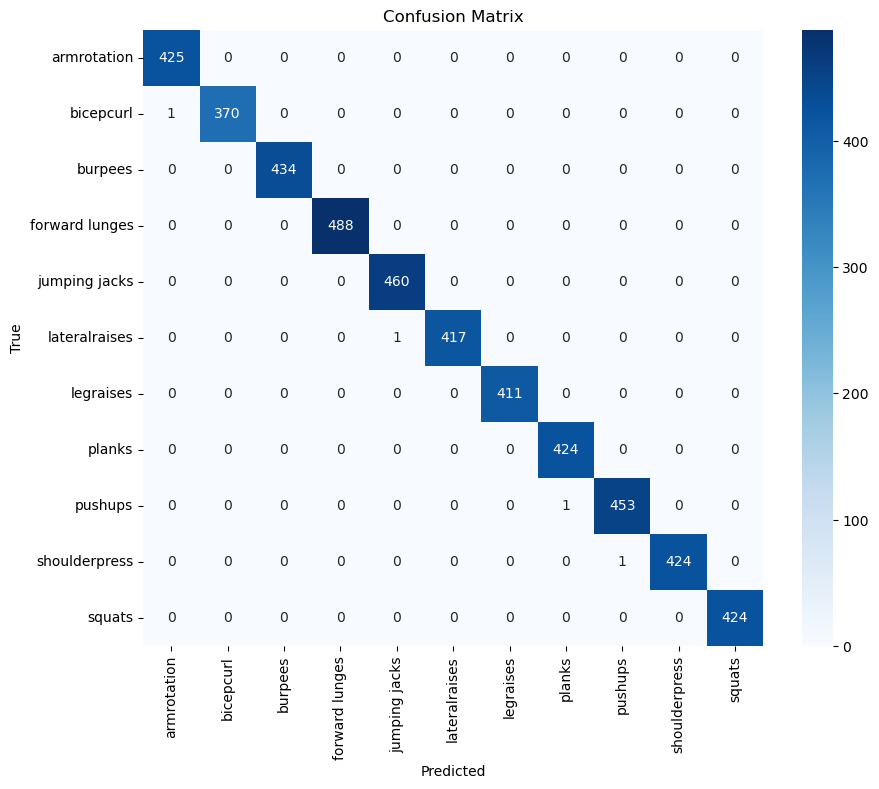

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [8]:
model.save("cnn_exercise_model.h5")
print("✅ Model saved as cnn_exercise_model.h5")


✅ Model saved as cnn_exercise_model.h5


In [12]:
from tensorflow.keras.models import load_model

model = load_model("cnn_exercise_model.h5")


In [14]:
import joblib

# After encoding labels
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

# Save label encoder
joblib.dump(le, "label_encoder.pkl")
print("✅ Saved label_encoder.pkl")


✅ Saved label_encoder.pkl


In [16]:
import cv2
import numpy as np
import mediapipe as mp
import joblib
from collections import deque
from tensorflow.keras.models import load_model

# Load model, scaler, and label encoder
model = load_model("cnn_exercise_model.h5")
scaler = joblib.load("scaler_cnn.pkl")
label_encoder = joblib.load("label_encoder.pkl")  # you should save this from training

# Constants
SEQUENCE_LENGTH = 30
NUM_ANGLES = 32

# Pose detection
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()
mp_drawing = mp.solutions.drawing_utils

# Buffer for sequences
sequence = deque(maxlen=SEQUENCE_LENGTH)

# Angle calculation helper
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

# Define angle triplets (based on MediaPipe index)
ANGLE_TRIPLETS = [
    (11, 13, 15), (13, 11, 23), (11, 23, 25), (23, 25, 27), (25, 27, 31),
    (15, 13, 11), (13, 15, 21), (15, 21, 19), (12, 14, 16), (14, 12, 24),
    (12, 24, 26), (24, 26, 28), (26, 28, 32), (16, 14, 12), (14, 16, 22),
    (16, 22, 20), (11, 12, 24), (23, 24, 12), (23, 11, 12), (24, 12, 11),
    (23, 25, 27), (25, 27, 29), (27, 29, 31), (24, 26, 28), (26, 28, 30),
    (28, 30, 32), (23, 25, 31), (24, 26, 32), (25, 23, 11), (26, 24, 12),
    (11, 23, 25), (12, 24, 26)
]

# OpenCV video
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Flip and convert
    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = pose.process(rgb)

    if result.pose_landmarks:
        landmarks = result.pose_landmarks.landmark
        # Calculate angles
        angles = []
        for a, b, c in ANGLE_TRIPLETS:
            angle = calculate_angle(
                [landmarks[a].x, landmarks[a].y],
                [landmarks[b].x, landmarks[b].y],
                [landmarks[c].x, landmarks[c].y]
            )
            angles.append(angle)

        if len(angles) == NUM_ANGLES:
            # Normalize and append to sequence
            angles_np = np.array(angles).reshape(1, -1)
            angles_scaled = scaler.transform(angles_np)
            sequence.append(angles_scaled[0])

        # If we have enough frames
        if len(sequence) == SEQUENCE_LENGTH:
            input_seq = np.array(sequence).reshape(1, SEQUENCE_LENGTH, NUM_ANGLES)
            prediction = model.predict(input_seq, verbose=0)
            class_id = np.argmax(prediction)
            label = label_encoder.inverse_transform([class_id])[0]
            confidence = np.max(prediction)

            # Show on frame
            cv2.putText(frame, f'{label} ({confidence:.2f})',
                        (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 0), 2)

        # Draw landmarks
        mp_drawing.draw_landmarks(frame, result.pose_landmarks, mp_pose.POSE_CONNECTIONS)

    # Display
    cv2.imshow("Exercise Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()
